In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras import Sequential,callbacks
from keras.layers import Dense,Conv2D,MaxPooling2D,BatchNormalization,Dropout, GlobalAveragePooling2D
from keras.layers import RandomFlip, RandomRotation, RandomTranslation, RandomZoom
import matplotlib.pyplot as plt
from sklearn.metrics import *
import seaborn as sns

I0000 00:00:1783946716.577070    1681 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783946716.879675    1681 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783946718.540325    1681 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
train_dir=r"/mnt/d/deep learning/projects/testing/train"
test_dir=r"/mnt/d/deep learning/projects/testing/test"


In [9]:
BATCH_SIZE = 128
IMAGE_SIZE = (48, 48)

train_ds_raw = keras.utils.image_dataset_from_directory(
    directory=train_dir,
    labels='inferred',
    label_mode='int',
    class_names=None,
    image_size=IMAGE_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds_raw = keras.utils.image_dataset_from_directory(
    directory=test_dir,
    labels='inferred',
    label_mode='int',
    class_names=None,
    image_size=IMAGE_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 28273 files belonging to 6 classes.
Found 6507 files belonging to 6 classes.


In [10]:
class_names = train_ds_raw.class_names
print(class_names)
# expected: ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']

['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [11]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds_raw.map(lambda x, y: (x / 255.0, y), num_parallel_calls=AUTOTUNE)
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

test_ds = test_ds_raw.map(lambda x, y: (x / 255.0, y), num_parallel_calls=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [12]:
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(factor=0.03),
    RandomTranslation(height_factor=0.1, width_factor=0.1, fill_mode="nearest"),
    RandomZoom(height_factor=0.1, fill_mode="nearest")
])

In [13]:
model = Sequential()

model.add(keras.layers.Input(shape=(48, 48, 1)))
model.add(data_augmentation)

# Conv Block 1
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Conv Block 2
model.add(Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.30))

# Conv Block 3
model.add(Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.40))

# Head
model.add(GlobalAveragePooling2D())
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.50))

# 6 classes now (disgust removed)
model.add(Dense(6, activation='softmax', dtype='float32'))

In [14]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,216,198 (4.64 MB)

 Trainable params: 1,213,894 (4.63 MB)

 Non-trainable params: 2,304 (9.00 KB)

In [15]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

In [16]:
model_check_point = callbacks.ModelCheckpoint(
    "100_epochs_6class.keras",
    monitor='val_loss',
    verbose=1,
    save_best_only=True
)

early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    verbose=1,
    restore_best_weights=True
)

reduce_lr_on_plateau = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=7,
    verbose=1
)

callback_list = [model_check_point, early_stopping, reduce_lr_on_plateau]

In [17]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=100,
    callbacks=callback_list,
    shuffle=False
)

Epoch 1/100


E0000 00:00:1783944030.665104    5239 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1783944040.989132    6193 shuffle_dataset_op.cc:453] ShuffleDatasetV3:28: Filling up shuffle buffer (this may take a while): 94 of 1000
I0000 00:00:1783944050.946330    6193 shuffle_dataset_op.cc:453] ShuffleDatasetV3:28: Filling up shuffle buffer (this may take a while): 204 of 1000
I0000 00:00:1783944052.833456    6193 shuffle_dataset_op.cc:483] Shuffle buffer filled.
I0000 00:00:1783944053.364045    5541 cuda_dnn.cc:461] Loaded cuDNN version 92400


221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.2050 - loss: 2.1838
Epoch 1: val_loss improved from None to 1.98387, saving model to 100_epochs_6class.keras

Epoch 1: finished saving model to 100_epochs_6class.keras
221/221 ━━━━━━━━━━━━━━━━━━━━ 52s 107ms/step - accuracy: 0.2050 - loss: 2.1838 - val_accuracy: 0.2732 - val_loss: 1.9839 - learning_rate: 0.0010
Epoch 2/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.2782 - loss: 1.8053
Epoch 2: val_loss improved from 1.98387 to 1.66647, saving model to 100_epochs_6class.keras

Epoch 2: finished saving model to 100_epochs_6class.keras
221/221 ━━━━━━━━━━━━━━━━━━━━ 51s 86ms/step - accuracy: 0.2782 - loss: 1.8053 - val_accuracy: 0.2906 - val_loss: 1.6665 - learning_rate: 0.0010
Epoch 3/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.3997 - loss: 1.5249
Epoch 3: val_loss improved from 1.66647 to 1.54250, saving model to 100_epochs_6class.keras

Epoch 3: finished saving model to 100_epochs_6class.keras
221/221 ━━━

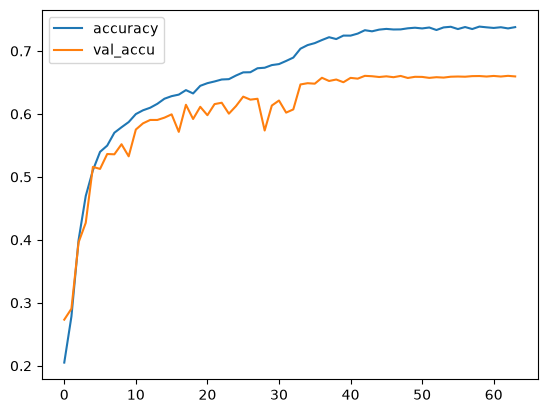

In [18]:
plt.plot(history.history['accuracy'],label='accuracy')
plt.plot(history.history['val_accuracy'],label='val_accu')
plt.legend()
plt.show()

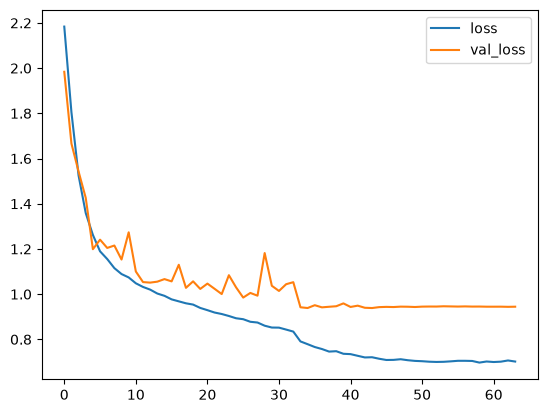

In [19]:
plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.legend()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step  
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
4/4 ━━━━━━━

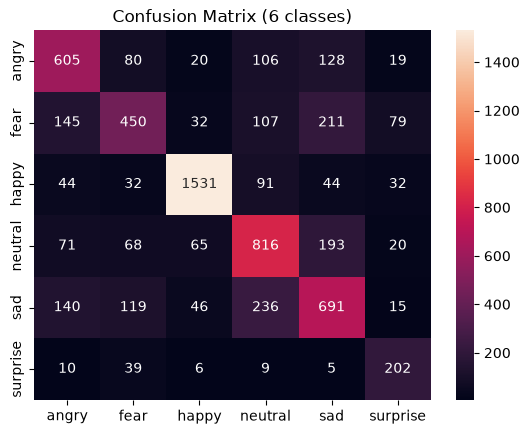

In [20]:
y_actual = []
y_pred = []

for images, labels in test_ds:
    prediction = model.predict(images, verbose=1)
    y_pred.extend(tf.argmax(prediction, axis=1).numpy())
    y_actual.extend(labels.numpy())

print(classification_report(y_actual, y_pred, target_names=class_names))

cm = confusion_matrix(y_actual, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (6 classes)")
plt.show()